In [7]:
import os
import jax
import zodiax as zdx
from zodiax.optimisation import sgd, adam
from jax import numpy as np, random as jr

jax.config.update("jax_enable_x64", True)

import amigo
import dorito
import astropy

# from optim_funcs import sgd, adam
from dLux import utils as dlu

# visualisation
import matplotlib.pyplot as plt
import matplotlib as mpl
import ehtplot
import scienceplots
import cmasher as cmr

# matplotlib parameters
plt.style.use(["science", "bright", "no-latex"])

plt.rcParams["image.cmap"] = "inferno"
plt.rcParams["font.family"] = "serif"
plt.rcParams["image.origin"] = "lower"
plt.rcParams["figure.dpi"] = 300
plt.rcParams["font.size"] = 8
plt.rcParams["xtick.direction"] = "out"
plt.rcParams["ytick.direction"] = "out"

inferno = mpl.colormaps["inferno"]
viridis = mpl.colormaps["viridis"]
seismic = mpl.colormaps["seismic"]

inferno.set_bad("k", 0.5)
viridis.set_bad("k", 0.5)
seismic.set_bad("k", 0.5)

In [8]:
from socket import gethostname

if gethostname() == "glinton":
    morgana = "/media/morgana1/"
else:
    morgana = "/Volumes/morgana1/"

amigo_cache = os.path.join(morgana, "snert/max/data/amigo_files/")

cache = os.path.join(amigo_cache, "v_0.0.10/")
output_path = os.path.join(amigo_cache, "outputs/easy_binary/")

load_dict = lambda x: np.load(x, allow_pickle=True).item()
cal_vis_outputs = load_dict(os.path.join(output_path, "cal_vis.npy"))

print(cal_vis_outputs.keys())

dict_keys(['F380M', 'F430M', 'F480M'])


In [9]:
optics_diameter = 6.603464  # JWST aperture diameter in meters
otf_coords = dlu.pixel_coords(51, 2 * optics_diameter)

ois = [
    dorito.model_fits.ResolvedOIFit(oi_data, key, filter=key[:5])
    for key, oi_data in cal_vis_outputs.items()
]
for oi in ois:
    print(oi.key)

# ois = ois[2:]
ois = [ois[-1]]


distribution = np.ones((51, 51))

model = dorito.models.ResolvedDiscoModel(
    ois,
    distribution,
    uv_npixels=2 * otf_coords.shape[-1],
    uv_pscale=0.5 * np.diff(otf_coords[0, 0]).mean(),
    oversample=2.0,
)

F380M
F430M
F480M


In [17]:
ois

[ResolvedOIFit(
   u=f64[1300],
   v=f64[1300],
   wavel=f64[],
   parang=f64[],
   vis=f64[349],
   d_vis=f64[349],
   phi=f64[349],
   d_phi=f64[349],
   vis_mat=f64[349,1300],
   phi_mat=f64[349,1300],
   key='F480M',
   filter='F480M'
 )]

In [ ]:
def normalise_distribution(model_params, args):
    params = model_params.params

    if "log_dist" in params.keys():
        for k, log_dist in params["log_dist"].items():
            distribution = 10**log_dist

            # centre = distribution.shape[0] // 2
            # norm = distribution[centre, centre]

            norm = distribution.sum()

            params["log_dist"][k] = np.log10(distribution / norm)

    return model_params.set("params", params), args


def looper(looper, loss_dict):
    loss = np.array([v[-1] for v in loss_dict.values()]).mean(0)
    looper.set_description(f"Loss: {loss:.6e}")


def log_likelihood(model, oi, args={}):
    data = np.concatenate([oi.vis, oi.phi])
    err = np.concatenate([oi.d_vis, oi.d_phi])
    model_vis = oi(model)  # same shape as data

    residual = data - model_vis
    nll = np.sum(0.5 * (residual / err) ** 2 + np.log(err * np.sqrt(2 * np.pi)))

    return nll


def phase_centre(model, oi, args={}):

    distribution = model.get_distribution(oi)

    # Tip/Tilt vectors (ramp in u,v)
    mu = oi.u / np.linalg.norm(oi.u)
    mv = oi.v / np.linalg.norm(oi.v)

    # to log visibilities
    cvis = oi.to_cvis(model, distribution)
    phase = np.angle(cvis)

    # calculating the phase centre of the distribution
    return np.hypot(np.dot(mu, phase), np.dot(mv, phase))

In [11]:
@zdx.filter_grad("log_dist")
def loss(model, exposure, args):
    return loss_fn(model, exposure, args)[0]


grads = loss(model, ois[0], {"reg_func_dict": {}, "reg_dict": {}})

/home/max/miniforge3/envs/ami/lib/python3.13/site-packages/jax/_src/numpy/lax_numpy.py:5555: ComplexWarning: Casting complex values to real discards the imaginary part
  out_array: Array = lax_internal._convert_element_type(


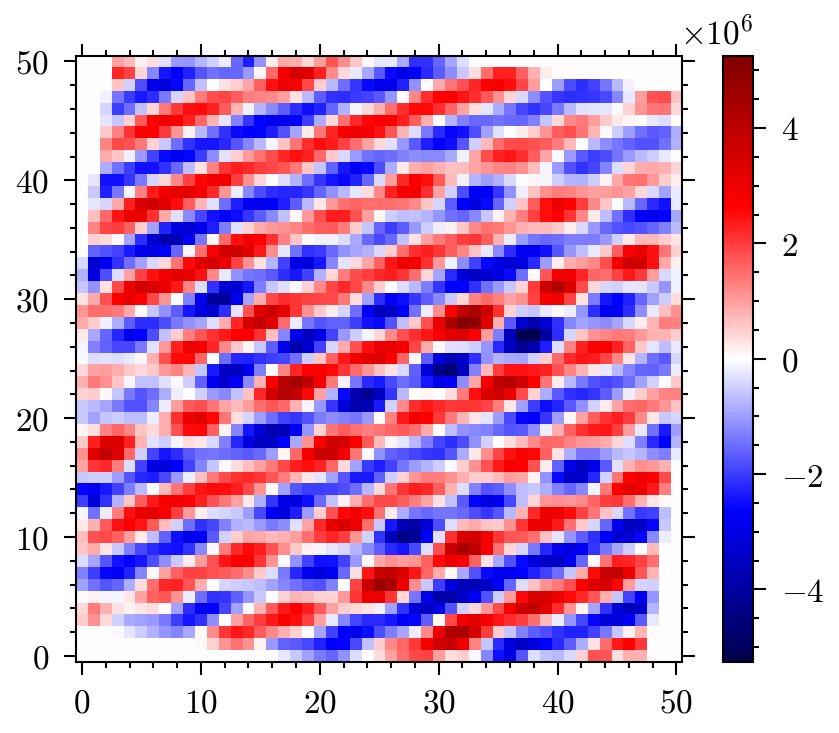

In [12]:
grad = grads.params["log_dist"]["F480M"]

plt.imshow(grad, cmap=seismic, norm=mpl.colors.CenteredNorm())
plt.colorbar()
plt.show()

In [ ]:
n_epoch = 2000
config = {
    # "log_dist": adam(2e-2, 0, (5000, 0.1)),
    "log_dist": adam(5e-4, 0),
    # "log_dist": adam(5e-3, 0),
}
args = {
    "reg_dict": {
        # "ME": (2e2, ME),
    }
}

trainer = amigo.fitting.Trainer(
    # loss_fn=centered_loss_fn,
    loss_fn=dorito.stats.regularised_loss_fn,
    norm_fn=normalise_distribution,
    looper_fn=looper,
)

trainer = trainer.update_fishers(
    model=model,
    exposures=[],
    parameters=[],
)

# Train the model
result = trainer.train(
    model=model,
    optimisers=config,
    epochs=n_epoch,
    batches=ois,
    args=args,
)

0it [00:00, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]

Compiling Loss function...
Compiling update function...

Initial_loss Loss: 61,481,476.17
Estimated run time: 0:00:19
Full Time: 0:00:26
Final Loss: 4,018.88


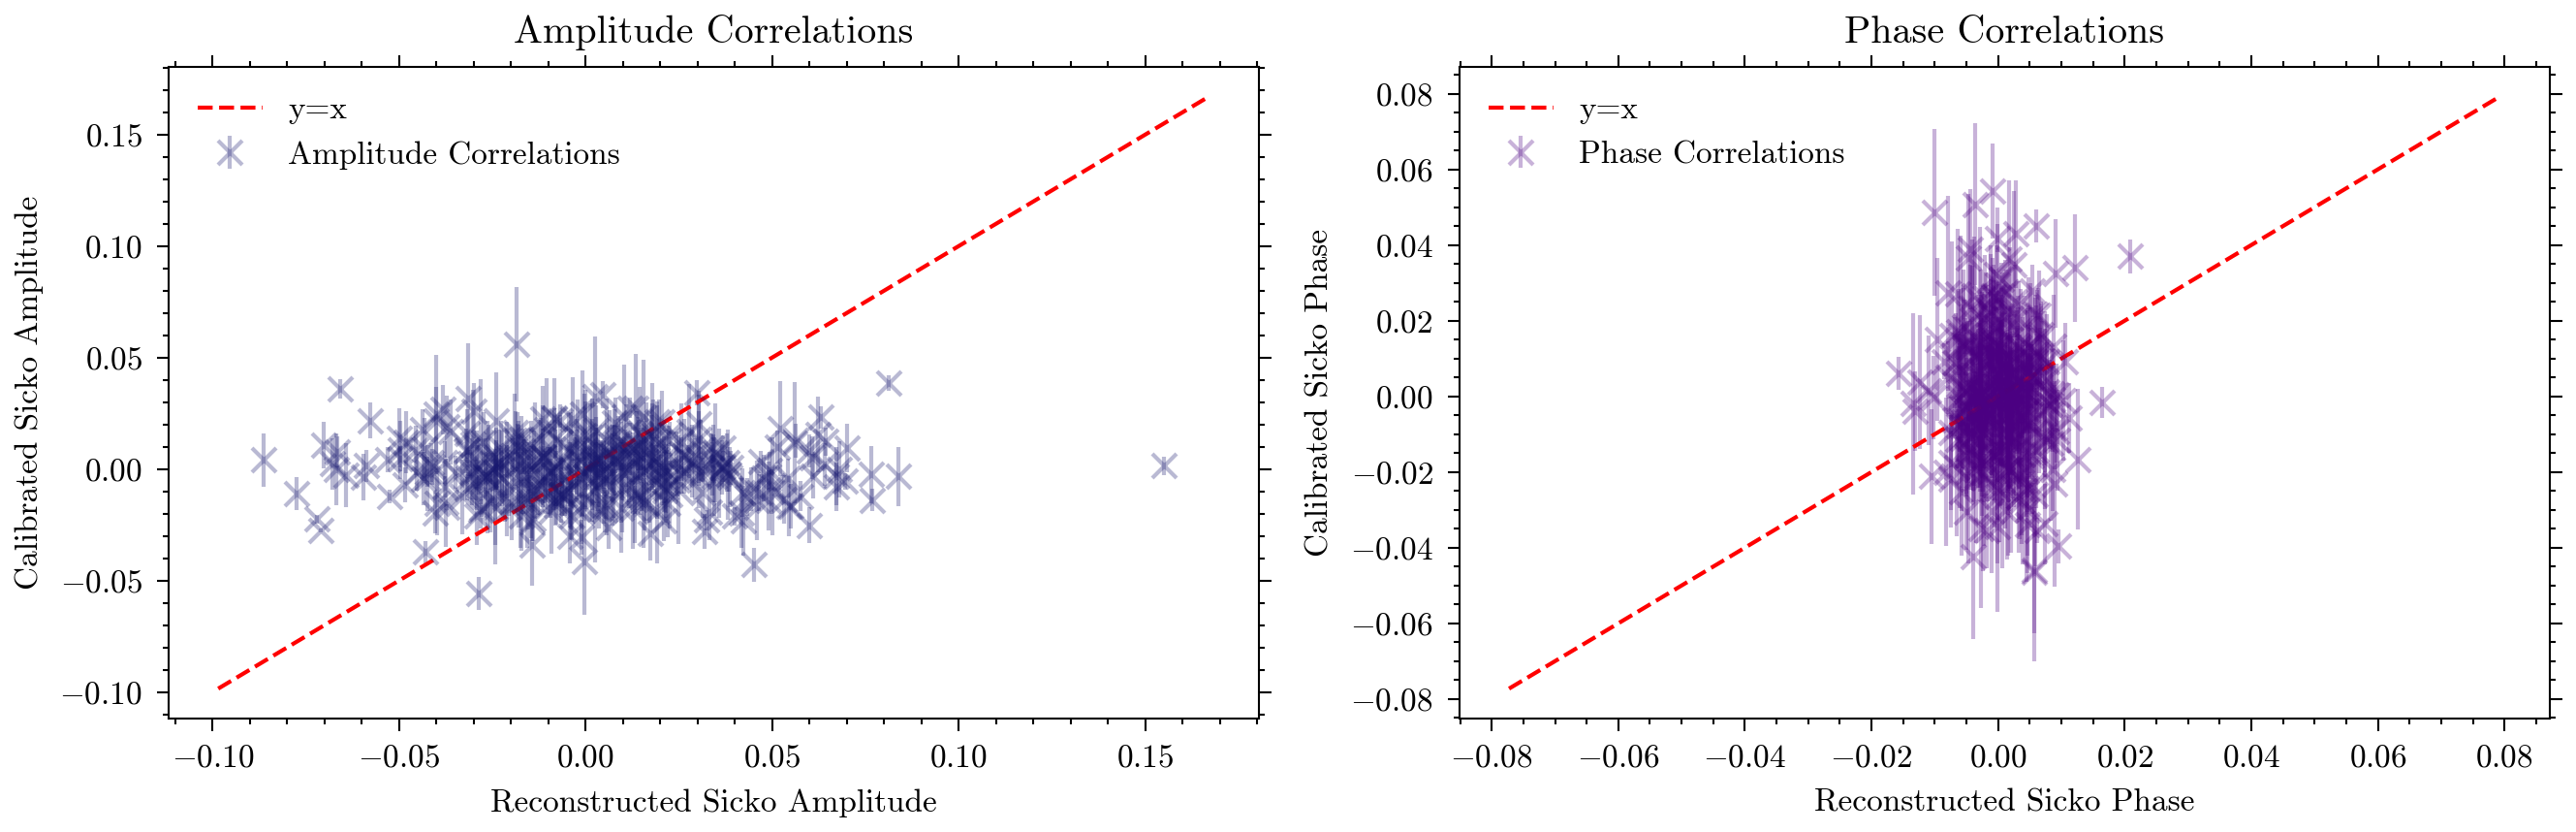

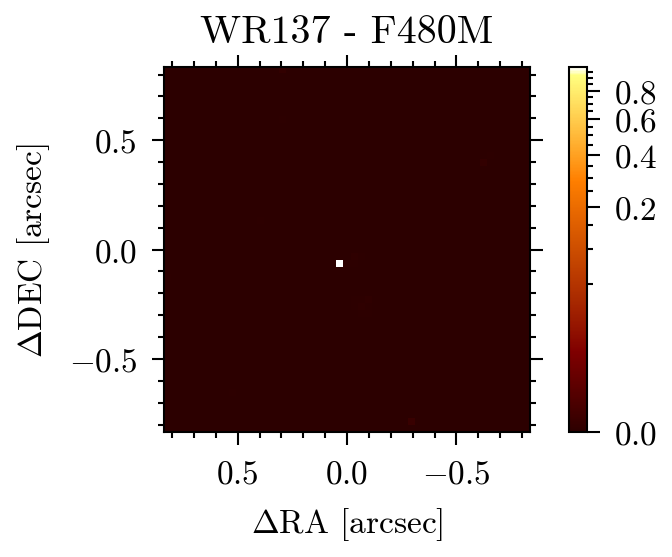

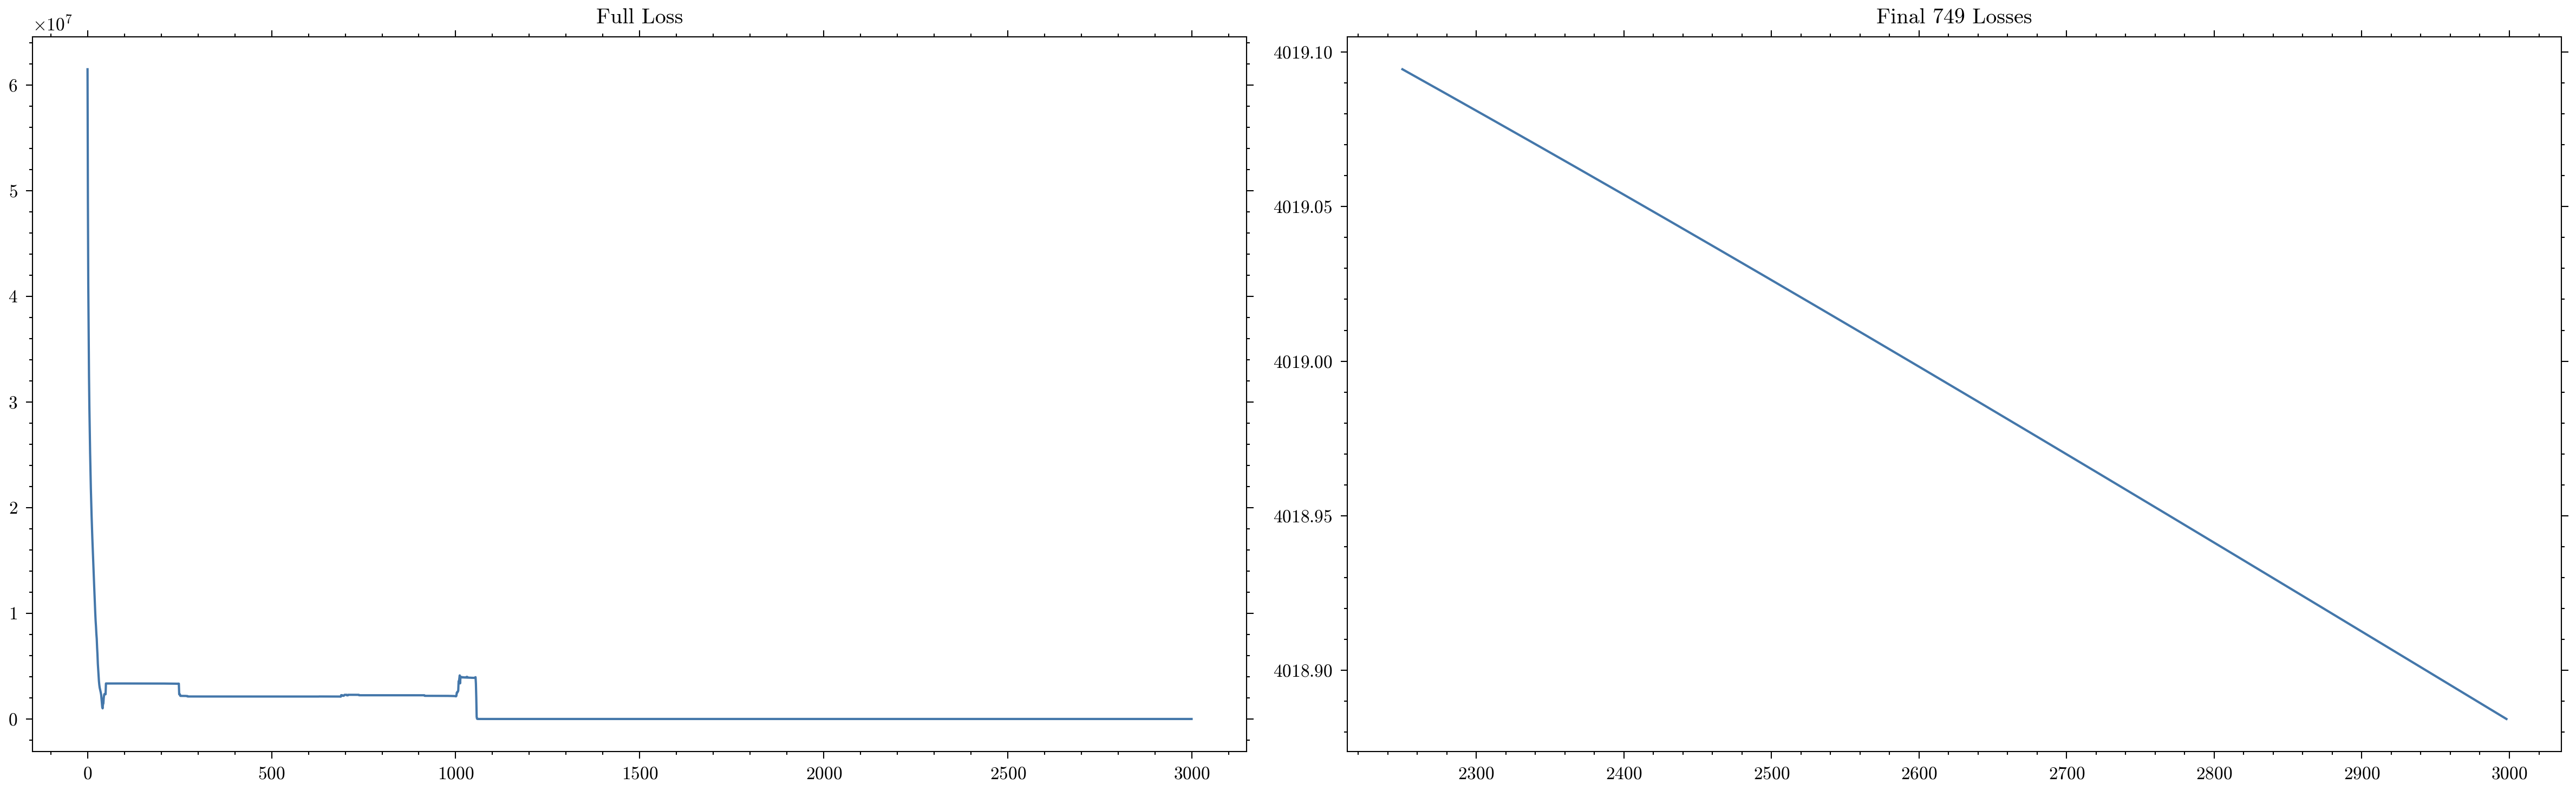

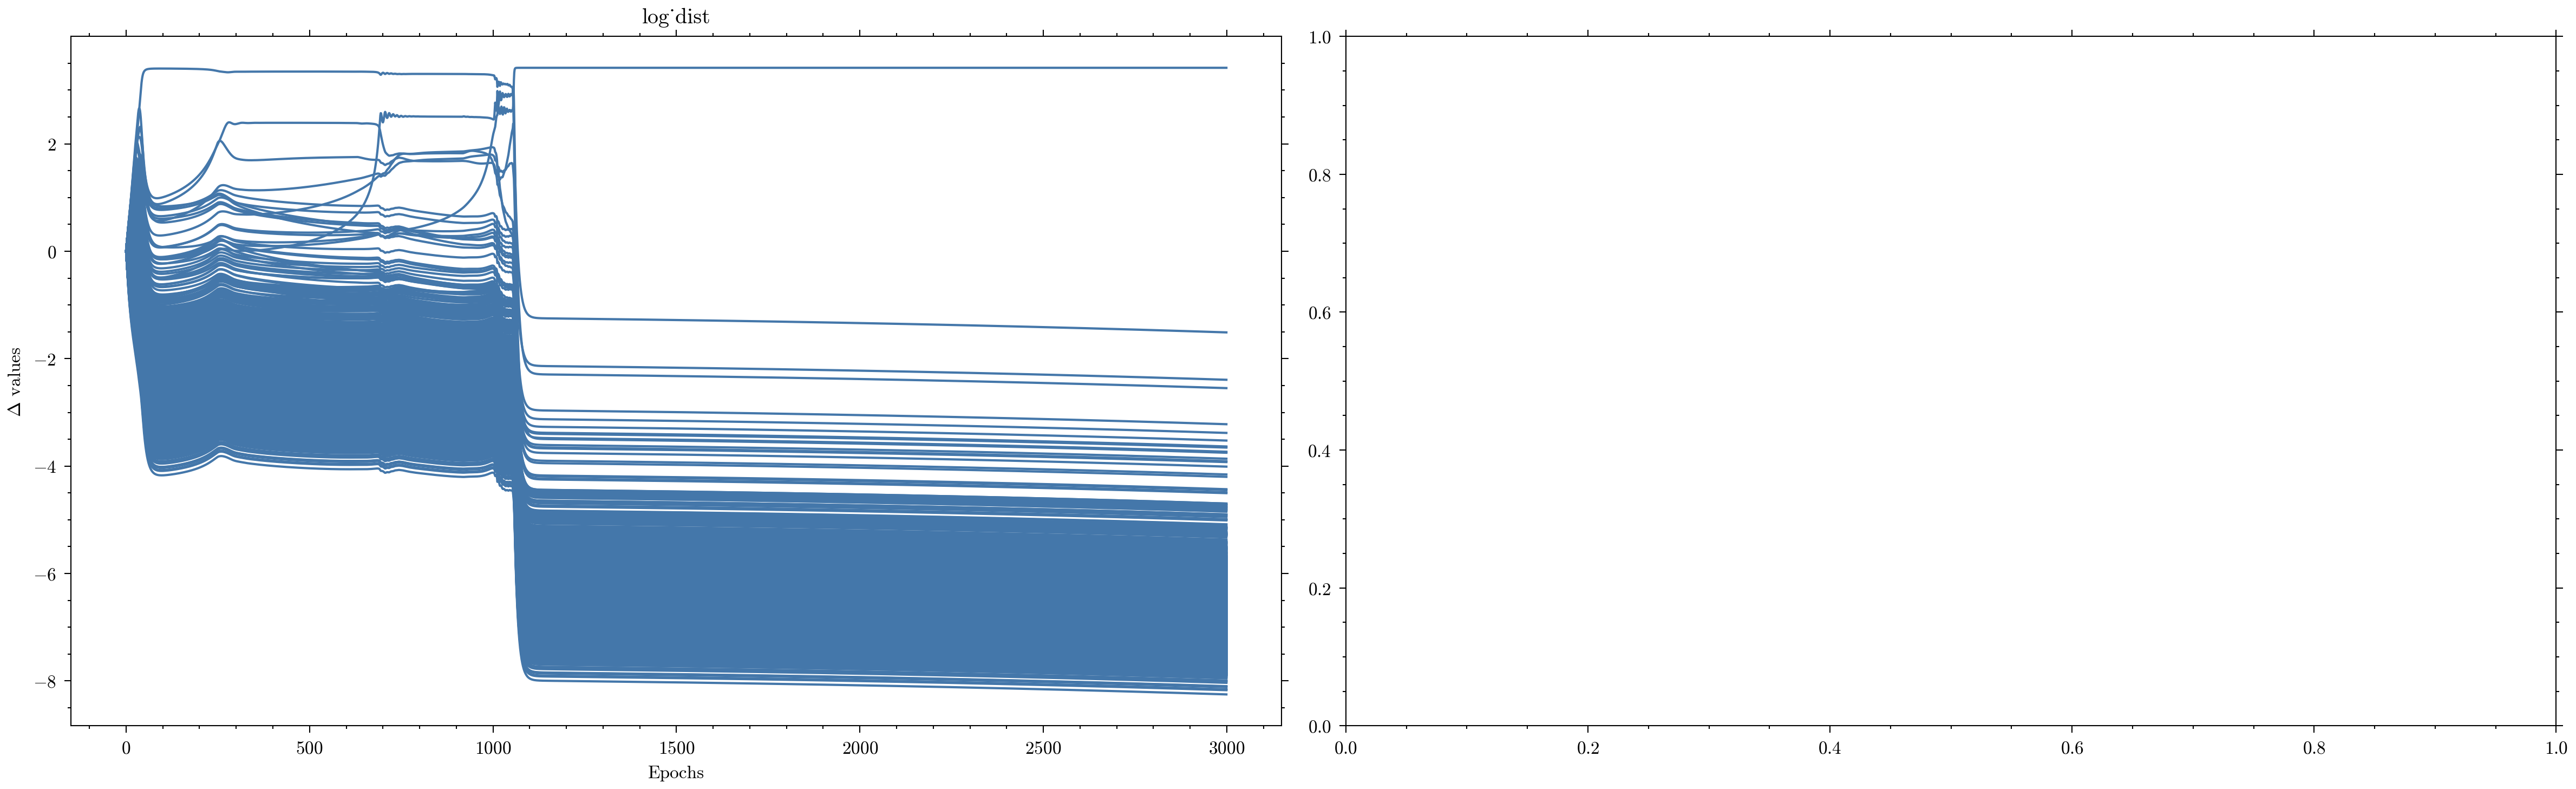

In [16]:
from amigo import plotting

for oi in ois:
    dist = 10 ** result.model.params["log_dist"][oi.get_key("log_dist")]

    disco_amp, disco_phase = np.split(oi(result.model), 2)

    fig, ax = plt.subplots(1, 2, figsize=(9, 3), sharey=False)

    ax[0].errorbar(
        disco_amp,
        oi.vis,
        yerr=oi.d_vis,
        label="Amplitude Correlations",
        fmt="x",
        alpha=0.3,
        color="midnightblue",
    )
    x_min, x_max = ax[0].get_xlim()
    y_min, y_max = ax[0].get_ylim()
    min_val = min(x_min, y_min)
    max_val = max(x_max, y_max)
    ax[0].plot([min_val, max_val], [min_val, max_val], "r--", label="y=x")
    ax[0].set_title("Amplitude Correlations")
    ax[0].set_xlabel("Reconstructed Sicko Amplitude")
    ax[0].set_ylabel("Calibrated Sicko Amplitude")
    ax[0].legend()

    ax[1].errorbar(
        disco_phase,
        oi.phi,
        yerr=oi.d_phi,
        label="Phase Correlations",
        fmt="x",
        alpha=0.3,
        color="indigo",
    )
    x_min, x_max = ax[1].get_xlim()
    y_min, y_max = ax[1].get_ylim()
    min_val = min(x_min, y_min)
    max_val = max(x_max, y_max)
    ax[1].plot([min_val, max_val], [min_val, max_val], "r--", label="y=x")
    ax[1].set_title("Phase Correlations")
    ax[1].set_xlabel("Reconstructed Sicko Phase")
    ax[1].set_ylabel("Calibrated Sicko Phase")
    ax[1].legend()

    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(3, 2))

    c0 = dorito.plotting.plot_result(
        ax,
        dist,
        pixel_scale=dlu.rad2arcsec(model.pscale_in),
        cmap="afmhot_10u",
        power=0.3,
        vmin=0,
    )

    fig.colorbar(c0)
    ax.set_title(f"WR137 - {oi.key}")
    plt.tight_layout()
    plt.show()

plotting.plot_losses(result.losses[0], start=int(n_epoch * 0.75))
plotting.plot(result.history)